# IntiVision Model Evaluation

This notebook evaluates the performance of the IntiVision CNN model using the validation dataset.

## Objectives

- Load trained model
- Load validation dataset
- Evaluate model performance
- Generate confusion matrix
- Generate classification report
- Analyze prediction errors

In [3]:
from pathlib import Path
import sys

import numpy as np
import tensorflow as tf

In [4]:
AI_SERVICE_DIR = Path.cwd().parent
SRC_DIR = AI_SERVICE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from config import (
    DATASET_DIR,
    GESTURE_CLASSES,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    MODEL_PATH,
)

print("AI service directory:", AI_SERVICE_DIR)
print("Dataset directory:", DATASET_DIR)
print("Model path:", MODEL_PATH)
print("Classes:", GESTURE_CLASSES)
print("Input size:", (IMAGE_HEIGHT, IMAGE_WIDTH))

AI service directory: /Users/serhaterbil/Desktop/intivision/ai-service
Dataset directory: /Users/serhaterbil/Desktop/intivision/ai-service/dataset
Model path: /Users/serhaterbil/Desktop/intivision/ai-service/models/intivision_v1.keras
Classes: ['stop', 'safe', 'not_safe', 'emergency', 'help_code']
Input size: (224, 224)


## 1. Load the Trained Model

In this section, the saved IntiVision model is loaded and its input, output and parameter information are verified.

In [5]:
model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully.")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Model parameters:", f"{model.count_params():,}")

Model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 5)
Model parameters: 11,169,605


## 2. Load the Validation Dataset

The validation dataset is loaded using the same image size, class order and normalization steps used during training.

In [6]:
from preprocess import load_datasets

train_dataset, validation_dataset = load_datasets()

print("Datasets loaded successfully.")
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())

Found 1000 files belonging to 5 classes.
Using 800 files for training.
Found 1000 files belonging to 5 classes.
Using 200 files for validation.
Datasets loaded successfully.
Training batches: 25
Validation batches: 7


## 3. Evaluate Model Performance

Evaluate the trained CNN model using the validation dataset.

In [7]:
loss, accuracy = model.evaluate(validation_dataset, verbose=1)

print(f"\nValidation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 1.0000 - loss: 0.0037

Validation Loss     : 0.0037
Validation Accuracy : 1.0000


## 4. Collect Validation Predictions

The model predictions and true labels are collected for confusion matrix and classification report analysis.

In [8]:
true_labels = []
predicted_labels = []
prediction_confidences = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)

    batch_predicted_labels = np.argmax(predictions, axis=1)
    batch_confidences = np.max(predictions, axis=1)

    true_labels.extend(labels.numpy())
    predicted_labels.extend(batch_predicted_labels)
    prediction_confidences.extend(batch_confidences)

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)
prediction_confidences = np.array(prediction_confidences)

print("Predictions collected successfully.")
print("Validation samples:", len(true_labels))
print("Correct predictions:", np.sum(true_labels == predicted_labels))
print("Incorrect predictions:", np.sum(true_labels != predicted_labels))

Predictions collected successfully.
Validation samples: 200
Correct predictions: 200
Incorrect predictions: 0


## 5. Confusion Matrix

The confusion matrix shows how the model classifies each gesture and whether any classes are confused with each other.

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

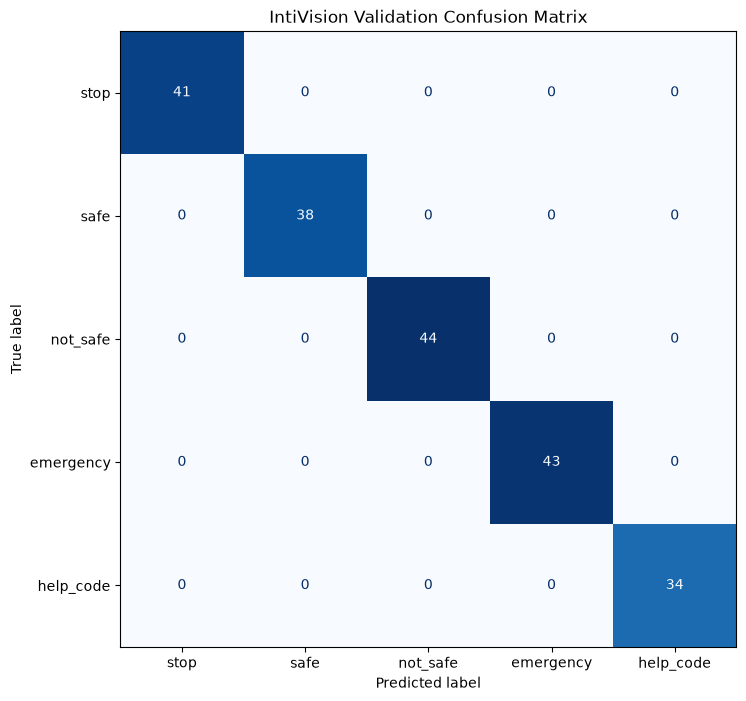

In [10]:
cm = confusion_matrix(
    true_labels,
    predicted_labels,
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=GESTURE_CLASSES,
)

fig, ax = plt.subplots(figsize=(8, 8))

display.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
)

plt.title("IntiVision Validation Confusion Matrix")
plt.show()

## 6. Classification Report

Generate precision, recall and F1-score for each gesture class.

In [11]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=GESTURE_CLASSES,
)

print(report)

              precision    recall  f1-score   support

        stop       1.00      1.00      1.00        41
        safe       1.00      1.00      1.00        38
    not_safe       1.00      1.00      1.00        44
   emergency       1.00      1.00      1.00        43
   help_code       1.00      1.00      1.00        34

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

